### feature_engineering.ipynb

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv('../data/processed/final_dataset.csv')

In [3]:
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [4]:
df.head()

,date,cpi,wpi
0,2012-04-01,97.8,104.7
1,2012-05-01,98.6,105.3
2,2012-06-01,99.8,105.3
3,2012-07-01,101.1,106.2
4,2012-08-01,102.2,106.9


#### Time Features

In [6]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year 
df['quarter'] = df['date'].dt.quarter

df[['date','month','year','quarter']].head()

,date,month,year,quarter
0,2012-04-01,4,2012,2
1,2012-05-01,5,2012,2
2,2012-06-01,6,2012,2
3,2012-07-01,7,2012,3
4,2012-08-01,8,2012,3


#### Lag Features

In [7]:
df['lag_1'] = df['cpi'].shift(1)
df['lag_2'] = df['cpi'].shift(2)
df['lag_3'] = df['cpi'].shift(3)
df['lag_6'] = df['cpi'].shift(6)
df['lag_12'] = df['cpi'].shift(12)

df[['cpi','lag_1','lag_2']].head(10)

,cpi,lag_1,lag_2
0,97.8,NaN,NaN
1,98.6,97.8,NaN
2,99.8,98.6,97.8
3,101.1,99.8,98.6
4,102.2,101.1,99.8
5,102.9,102.2,101.1
6,103.6,102.9,102.2
7,104.3,103.6,102.9
8,104.6,104.3,103.6
9,104.6,104.6,104.3


#### Rolling Features

In [8]:
df['rolling_mean_3'] = df['cpi'].rolling(3).mean()
df['rolling_std_3'] = df['cpi'].rolling(3).std()

df['rolling_mean_6'] = df['cpi'].rolling(6).mean()
df['rolling_std_6'] = df['cpi'].rolling(6).std()

#### Growth (Inflation %)

In [9]:
df['cpi_pct_change'] = df['cpi'].pct_change() * 100

df[['cpi','cpi_pct_change']].head()

,cpi,cpi_pct_change
0,97.8,NaN
1,98.6,0.817996
2,99.8,1.217039
3,101.1,1.302605
4,102.2,1.088032


#### Difference Feature

In [10]:
df['cpi_diff'] = df['cpi'].diff()
df['cpi_diff'].head()

0    NaN
1    0.8
2    1.2
3    1.3
4    1.1
Name: cpi_diff, dtype: float64

## WPI Features

In [11]:
df['wpi_pct_change'] = df['wpi'].pct_change() * 100
df['wpi_lag1'] = df['wpi'].shift(1)

In [12]:
df['trend_index'] = range(len(df))
df['cpi_wpi_diff'] = df['cpi'] - df['wpi']

In [13]:
df = df.dropna()

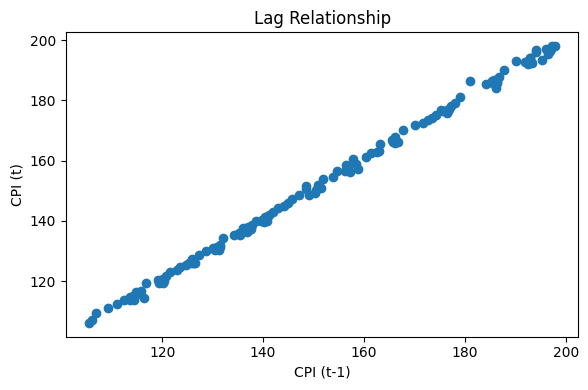

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df['lag_1'], df['cpi'])

plt.xlabel("CPI (t-1)")
plt.ylabel("CPI (t)")
plt.title("Lag Relationship")

plt.tight_layout()
plt.savefig('../reports/lag_feature.png')

plt.show()

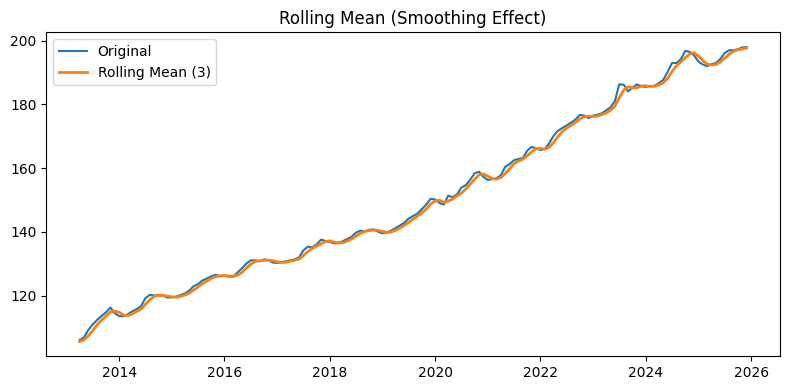

In [15]:
plt.figure(figsize=(8,4))

plt.plot(df['date'], df['cpi'], label='Original')
plt.plot(df['date'], df['rolling_mean_3'], label='Rolling Mean (3)', linewidth=2)

plt.legend()
plt.title("Rolling Mean (Smoothing Effect)")

plt.tight_layout()
plt.savefig('../reports/rolling_feature.png')

plt.show()

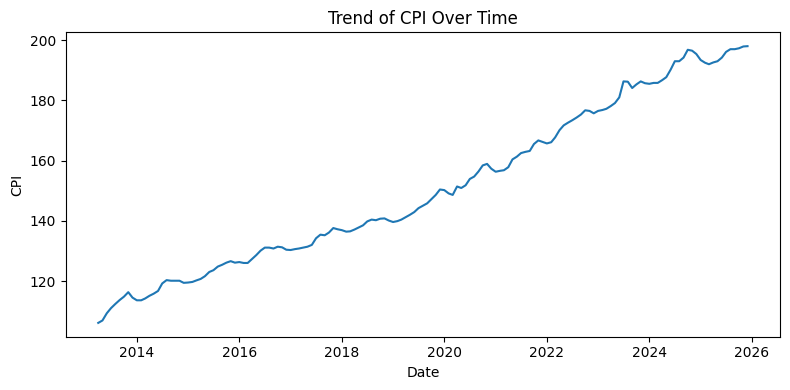

In [16]:
plt.figure(figsize=(8,4))

plt.plot(df['date'], df['cpi'], label='CPI')

plt.title("Trend of CPI Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.tight_layout()
plt.savefig('../reports/trend_feature.png')

plt.show()

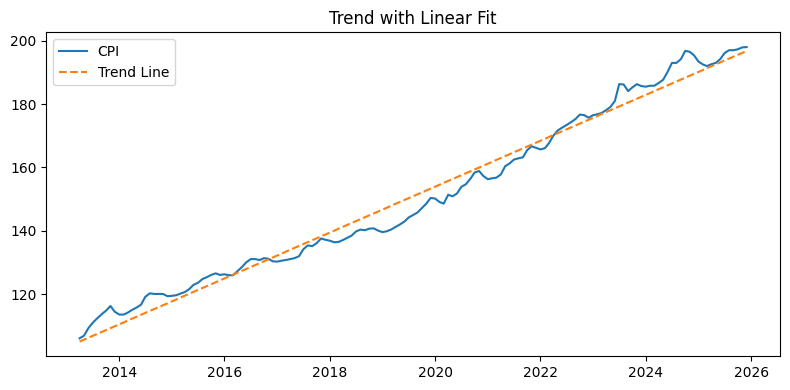

In [17]:
import numpy as np

x = np.arange(len(df))
y = df['cpi']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(8,4))
plt.plot(df['date'], y, label='CPI')
plt.plot(df['date'], p(x), linestyle='--', label='Trend Line')

plt.legend()
plt.title("Trend with Linear Fit")

plt.tight_layout()
plt.savefig('../reports/trend_line.png')

plt.show()

In [22]:
df.tail()

,date,cpi,wpi,month,year,quarter,lag_1,lag_2,lag_3,lag_6,...,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,cpi_pct_change,cpi_diff,wpi_pct_change,wpi_lag1,trend_index,cpi_wpi_diff
160,2025-08-01,197.0,155.2,8,2025,3,196.1,194.2,193.0,192.5,...,195.766667,1.429452,194.150000,2.013703,0.458950,0.9,0.518135,154.4,160,41.8
161,2025-09-01,197.0,155.0,9,2025,3,197.0,196.1,194.2,192.0,...,196.700000,0.519615,194.983333,1.980320,0.000000,0.0,-0.128866,155.2,161,42.0
162,2025-10-01,197.3,155.1,10,2025,4,197.0,197.0,196.1,192.6,...,197.100000,0.173205,195.766667,1.767107,0.152284,0.3,0.064516,155.0,162,42.2
163,2025-11-01,197.9,156.2,11,2025,4,197.3,197.0,197.0,193.0,...,197.400000,0.458258,196.583333,1.304479,0.304105,0.6,0.709220,155.1,163,41.7
164,2025-12-01,198.0,157.2,12,2025,4,197.9,197.3,197.0,194.2,...,197.733333,0.378594,197.216667,0.696898,0.050531,0.1,0.640205,156.2,164,40.8


In [23]:
df.to_csv('../data/processed/final_features.csv', index=False)